# NumerAI Rapid Research Template

In [34]:
import sys
import warnings
from pathlib import Path
import os

import pandas as pd
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")

try:
    NOTEBOOK_PATH = Path(__file__).resolve()
except NameError:
    NOTEBOOK_PATH = Path.cwd() / os.environ.get("JPY_SESSION_NAME", "notebook.ipynb")
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    read_parquet_with_id_index,
)
from utils.metrics import calculate_metrics
from utils.model_benchmark import compare_top_models_with_current, record_model_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
print('>> Current Notebook Path:', NOTEBOOK_PATH)

>> Current Notebook Path: c:\dev\numer-AI\models\version_1\v1.5\notebook.ipynb


In [35]:
snnr_df = pd.read_csv("../../../exploratory_notebooks/outputs/snnr_weights_vs_correlation_v5.2.csv")
AUXILIARY_TARGETS = snnr_df["auxiliary_target"].tolist()
print('>> Auxiliary Targets:', AUXILIARY_TARGETS)

>> Auxiliary Targets: ['target_jasper_20', 'target_teager2b_20', 'target_claudia_20', 'target_rowan_20', 'target_waldo_20', 'target_ender_60', 'target_xerxes_20', 'target_jeremy_20', 'target_cyrusd_20', 'target_agnes_20', 'target_victor_20', 'target_ralph_20', 'target_caroline_20', 'target_delta_20', 'target_tyler_20', 'target_sam_20', 'target_echo_20']


In [36]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"] # , "intelligence", "dexterity", "charisma", "wisdom", "strength", "constitution"]
CUSTOM_FEATURE_LIST = None
MAIN_TARGET = "target_ender_20"
TARGET_COL = [MAIN_TARGET] + AUXILIARY_TARGETS
BENCHMARK_COL = "v52_lgbm_ender20"

# Data loading mode flags
USE_STANDARD_LOADER = True
ALIGN_VALIDATION_BENCHMARKS = True

# Train/validation embargo (train -> validation)
EMBARGO_ERAS = 4

# Stacking split policy inside TRAIN (tail eras reserved for meta-learner; validation is evaluation-only)
META_TAIL_PCT = 0.10
META_EMBARGO_ERAS = 4

# Meta model defaults
META_MODEL_ALPHA = 1.0e-6
ENABLE_NEUTRALIZATION = False
NEUTRALIZATION_PROPORTION = 0.25

# Notebook run controls
MODEL_NAME = "fa_v1.5.0_ridge_stacking_tail10"
FORCE_HISTORY_OVERWRITE = True
RECORD_HISTORY = False
RETRAIN_ON_FULL_DATA = False


## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [37]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

train_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=TARGET_COL,
)
validation_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=TARGET_COL,
)

train_source = Path(TRAIN_PATH) if TRAIN_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "train.parquet"
validation_source = Path(VALIDATION_PATH) if VALIDATION_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "validation.parquet"
benchmark_source = (
    Path(VALIDATION_BENCHMARKS_PATH)
    if VALIDATION_BENCHMARKS_PATH is not None
    else Path(DATA_DIR) / DATA_VERSION / "validation_benchmark_models.parquet"
)

train = read_parquet_with_id_index(train_source, columns=train_columns)
validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
validation = apply_validation_embargo(
    train=train,
    validation=validation,
    embargo_eras=EMBARGO_ERAS,
)

val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)

# Train needs all auxiliary targets for specialist training; validation is evaluated on main target only.
train = train.dropna(subset=TARGET_COL)
validation = validation.dropna(subset=[MAIN_TARGET])

if ALIGN_VALIDATION_BENCHMARKS:
    validation, val_benchmarks = align_on_id(validation, val_benchmarks)

print("Loader mode     :", "standard" if USE_STANDARD_LOADER else "custom")
print("Train shape     :", train.shape)
print("Validation shape:", validation.shape)
print("Feature count   :", len(feature_set))
print("Benchmark col   :", BENCHMARK_COL)

print("\nValidation data sample:")
display(validation.head())


Loader mode     : standard
Train shape     : (2732873, 61)
Validation shape: (3886183, 61)
Feature count   : 42
Benchmark col   : v52_lgbm_ender20

Validation data sample:


,era,target_ender_20,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20,target_caroline_20,target_delta_20,target_tyler_20,target_sam_20,target_echo_20,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,feature_donnard_groutier_twinkle,feature_elusive_vapoury_accomplice,feature_geminate_crummiest_scourer,feature_glandered_unimproved_peafowl,feature_hempen_unionist_cone,feature_illuminated_gambrel_noria,feature_jacobinical_symmetric_roll,feature_jewish_stained_disembowelment,feature_lacklustre_centroidal_schweitzer,feature_limiest_heliolithic_york,feature_maledictive_latter_psellism,feature_mendelian_undiscording_avion,feature_musicianly_aspirate_creativity,feature_petty_upraised_caddice,feature_pottier_unmanly_collyrium,feature_reclaimed_insurrectional_moneyer,feature_saddening_unsound_rustling,feature_simulated_nonclassified_intercessor,feature_snakiest_somalian_wavelet,feature_splanchnic_notional_pint,feature_strained_equivocal_phoneme,feature_stretchy_spiniest_fizgig,feature_toltec_korean_disfavourer,feature_transisthmian_yogic_linden,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
n000c290e4364875,0579,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.25,0.50,0.50,0.50,0.50,0.5,0.50,0.50,2,2,3,2,2,3,3,2,2,0,2,0,2,3,2,4,4,2,2,2,0,3,2,1,2,2,1,2,1,2,4,2,3,2,1,1,1,2,2,1,0,2
n002a15bc5575bbb,0579,0.25,0.25,0.50,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.25,0.5,0.25,0.25,0,4,4,0,1,3,1,1,1,2,1,2,3,0,3,1,1,4,1,1,0,4,3,1,1,4,3,2,0,3,3,1,1,1,1,2,1,4,4,1,1,1
n00309caaa0f955e,0579,0.75,0.75,0.75,0.75,0.75,0.50,0.75,0.75,0.50,0.75,0.75,0.50,0.75,0.75,0.75,0.5,0.50,0.75,1,1,4,4,0,3,1,4,3,4,3,0,1,4,1,2,2,0,2,3,3,4,4,0,1,4,4,0,0,4,3,1,1,0,0,0,0,1,1,1,4,3
n0039cbdcf835708,0579,0.50,0.50,0.50,0.50,0.50,0.50,0.75,0.50,0.50,0.50,0.25,0.25,0.50,0.50,0.50,0.5,0.50,0.50,2,2,3,1,4,3,4,3,4,0,2,0,2,3,2,4,4,4,3,2,2,3,1,3,0,2,0,4,2,2,0,2,1,4,3,2,3,3,1,3,2,2
n004143458984f89,0579,0.50,0.50,0.50,0.50,0.50,0.50,0.75,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.50,0.5,0.50,0.50,4,1,1,1,0,4,4,1,0,0,1,2,3,0,1,4,0,4,2,2,0,0,0,3,1,3,3,2,1,2,2,4,2,1,3,4,3,3,3,2,0,2


In [38]:
# Split TRAIN into specialist-train eras and meta-learner training tail.
# Validation is reserved for evaluation only — it is never used in any training step here.
train_era_int = train["era"].astype(int)
sorted_train_eras = sorted(train_era_int.unique())
total_train_eras = len(sorted_train_eras)

meta_train_tail_count = max(1, int(round(total_train_eras * META_TAIL_PCT)))
required_eras = meta_train_tail_count + META_EMBARGO_ERAS + 1
if total_train_eras < required_eras:
    raise ValueError(
        "Not enough training eras for split policy. "
        f"Need at least {required_eras}, found {total_train_eras}."
    )

meta_train_tail_eras = sorted_train_eras[-meta_train_tail_count:]
if META_EMBARGO_ERAS > 0:
    meta_train_embargo_eras = sorted_train_eras[
        -(meta_train_tail_count + META_EMBARGO_ERAS) : -meta_train_tail_count
    ]
else:
    meta_train_embargo_eras = []
specialist_train_eras = sorted_train_eras[
    : total_train_eras - meta_train_tail_count - META_EMBARGO_ERAS
]

specialist_train_frame = train.loc[train_era_int.isin(specialist_train_eras)].copy()
meta_train_frame = train.loc[train_era_int.isin(meta_train_tail_eras)].copy()

if len(specialist_train_frame) == 0 or len(meta_train_frame) == 0:
    raise ValueError("Split produced an empty frame; adjust META_TAIL_PCT or META_EMBARGO_ERAS.")

if set(specialist_train_frame["era"].astype(int).unique()).intersection(
    set(meta_train_frame["era"].astype(int).unique())
):
    raise ValueError("Leakage guard failed: specialist and meta train eras overlap.")

print("Train era range             :", (train["era"].min(), train["era"].max()))
print("Specialist train eras       :", (specialist_train_frame["era"].min(), specialist_train_frame["era"].max()))
print("Meta-train tail eras        :", (meta_train_frame["era"].min(), meta_train_frame["era"].max()))
print("Meta embargo eras excluded  :", len(meta_train_embargo_eras))
print("Specialist train rows       :", specialist_train_frame.shape[0])
print("Meta-train rows             :", meta_train_frame.shape[0])
print("Validation rows (full eval) :", validation.shape[0])


Train era range             : ('0001', '0574')
Specialist train eras       : ('0001', '0513')
Meta-train tail eras        : ('0518', '0574')
Meta embargo eras excluded  : 4
Specialist train rows       : 2408902
Meta-train rows             : 304771
Validation rows (full eval) : 3886183


## 2) Train Specialist Models
Train one Ridge per auxiliary target on `specialist_train_frame` (train minus meta tail and embargo). Generate era-ranked out-of-sample predictions for the meta-training tail and for the **full** validation set.


In [39]:
import tqdm

TARGETS_TO_TRAIN = [
    target_name
    for target_name in AUXILIARY_TARGETS
    if target_name in specialist_train_frame.columns and target_name != MAIN_TARGET
]
if not TARGETS_TO_TRAIN:
    raise ValueError("No auxiliary targets available for specialist training.")

print("Training specialists on targets:", len(TARGETS_TO_TRAIN))

trained_ridge_models = {}
validation_ranked_predictions = {}
meta_ranked_predictions = {}
target_row_counts = {}

for target_name in tqdm.tqdm(
    TARGETS_TO_TRAIN,
    desc="Training Ridge specialists",
    unit="target",
):
    target_train_frame = specialist_train_frame.dropna(subset=[target_name]).copy()
    if target_train_frame.empty:
        continue

    X_train = target_train_frame[feature_set].to_numpy()
    y_train = target_train_frame[target_name].to_numpy()

    specialist_model = Ridge(alpha=1.0e-6, random_state=42)
    specialist_model.fit(X_train, y_train)
    trained_ridge_models[target_name] = specialist_model
    target_row_counts[target_name] = len(target_train_frame)

    # Predictions for full validation (evaluation set).
    val_raw = pd.Series(
        specialist_model.predict(validation[feature_set].to_numpy()),
        index=validation.index,
        name=target_name,
    )
    validation_ranked_predictions[target_name] = rank_by_era(
        predictions=val_raw,
        eras=validation["era"],
        index=validation.index,
    )

    # Predictions for meta-learner training tail (from train).
    meta_raw = pd.Series(
        specialist_model.predict(meta_train_frame[feature_set].to_numpy()),
        index=meta_train_frame.index,
        name=target_name,
    )
    meta_ranked_predictions[target_name] = rank_by_era(
        predictions=meta_raw,
        eras=meta_train_frame["era"],
        index=meta_train_frame.index,
    )

if not trained_ridge_models:
    raise ValueError("No specialist models were trained after target-specific NaN filtering.")

print("Specialists trained:", len(trained_ridge_models))
print(
    "Rows per specialist (train min/median/max):",
    min(target_row_counts.values()),
    int(pd.Series(target_row_counts).median()),
    max(target_row_counts.values()),
)


Training specialists on targets: 17


Training Ridge specialists: 100%|██████████| 17/17 [00:27<00:00,  1.61s/target]

Specialists trained: 17
Rows per specialist (train min/median/max): 2408902 2408902 2408902


In [40]:
# Assemble specialist rank-prediction matrices for stacking
validation_meta_features = pd.DataFrame(validation_ranked_predictions).sort_index()
meta_training_features = pd.DataFrame(meta_ranked_predictions).sort_index()

if validation_meta_features.empty or meta_training_features.empty:
    raise ValueError("Specialist prediction matrices are empty.")

print("Validation meta-feature shape:", validation_meta_features.shape)
print("Meta-training feature shape   :", meta_training_features.shape)
display(validation_meta_features.head())

Validation meta-feature shape: (3886183, 17)
Meta-training feature shape   : (304771, 17)


,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20,target_caroline_20,target_delta_20,target_tyler_20,target_sam_20,target_echo_20
id,,,,,,,,,,,,,,,,,
n000001c6d04d3ef,0.611047,0.606925,0.618137,0.590437,0.618796,0.562572,0.579720,0.576917,0.547733,0.740148,0.547568,0.625721,0.552844,0.704204,0.576752,0.566859,0.538005
n0000065fb5955c5,0.280145,0.283144,0.264678,0.307134,0.155461,0.314236,0.146938,0.326389,0.148990,0.192551,0.156566,0.143150,0.157828,0.451705,0.163037,0.149621,0.120896
n00000acaae936c8,0.203071,0.221466,0.211761,0.229867,0.326767,0.231460,0.205243,0.699450,0.207126,0.268250,0.217555,0.285197,0.229577,0.579085,0.359791,0.241020,0.240730
n00001041c3474c5,0.708202,0.714350,0.707302,0.736842,0.808067,0.764582,0.783926,0.814515,0.805068,0.614935,0.773429,0.788424,0.795622,0.908832,0.824112,0.798171,0.723197
n0000123b62b6d6d,0.740356,0.751566,0.680514,0.667821,0.851467,0.645401,0.796736,0.755523,0.814375,0.683317,0.789647,0.855589,0.829212,0.770195,0.847511,0.826574,0.813551


In [41]:
# Keep only specialist predictions as meta inputs (no mean/rank-average baseline).
validation_predictions_df = validation_meta_features.copy()
validation_predictions_df.head()

,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20,target_caroline_20,target_delta_20,target_tyler_20,target_sam_20,target_echo_20
id,,,,,,,,,,,,,,,,,
n000001c6d04d3ef,0.611047,0.606925,0.618137,0.590437,0.618796,0.562572,0.579720,0.576917,0.547733,0.740148,0.547568,0.625721,0.552844,0.704204,0.576752,0.566859,0.538005
n0000065fb5955c5,0.280145,0.283144,0.264678,0.307134,0.155461,0.314236,0.146938,0.326389,0.148990,0.192551,0.156566,0.143150,0.157828,0.451705,0.163037,0.149621,0.120896
n00000acaae936c8,0.203071,0.221466,0.211761,0.229867,0.326767,0.231460,0.205243,0.699450,0.207126,0.268250,0.217555,0.285197,0.229577,0.579085,0.359791,0.241020,0.240730
n00001041c3474c5,0.708202,0.714350,0.707302,0.736842,0.808067,0.764582,0.783926,0.814515,0.805068,0.614935,0.773429,0.788424,0.795622,0.908832,0.824112,0.798171,0.723197
n0000123b62b6d6d,0.740356,0.751566,0.680514,0.667821,0.851467,0.645401,0.796736,0.755523,0.814375,0.683317,0.789647,0.855589,0.829212,0.770195,0.847511,0.826574,0.813551


In [42]:
print(
    "Meta-feature matrix range (global min/max):",
    float(validation_meta_features.min().min()),
    float(validation_meta_features.max().max()),
)
display(validation_meta_features.head())

Meta-feature matrix range (global min/max): 0.00013681762210972773 1.0


,target_jasper_20,target_teager2b_20,target_claudia_20,target_rowan_20,target_waldo_20,target_ender_60,target_xerxes_20,target_jeremy_20,target_cyrusd_20,target_agnes_20,target_victor_20,target_ralph_20,target_caroline_20,target_delta_20,target_tyler_20,target_sam_20,target_echo_20
id,,,,,,,,,,,,,,,,,
n000001c6d04d3ef,0.611047,0.606925,0.618137,0.590437,0.618796,0.562572,0.579720,0.576917,0.547733,0.740148,0.547568,0.625721,0.552844,0.704204,0.576752,0.566859,0.538005
n0000065fb5955c5,0.280145,0.283144,0.264678,0.307134,0.155461,0.314236,0.146938,0.326389,0.148990,0.192551,0.156566,0.143150,0.157828,0.451705,0.163037,0.149621,0.120896
n00000acaae936c8,0.203071,0.221466,0.211761,0.229867,0.326767,0.231460,0.205243,0.699450,0.207126,0.268250,0.217555,0.285197,0.229577,0.579085,0.359791,0.241020,0.240730
n00001041c3474c5,0.708202,0.714350,0.707302,0.736842,0.808067,0.764582,0.783926,0.814515,0.805068,0.614935,0.773429,0.788424,0.795622,0.908832,0.824112,0.798171,0.723197
n0000123b62b6d6d,0.740356,0.751566,0.680514,0.667821,0.851467,0.645401,0.796736,0.755523,0.814375,0.683317,0.789647,0.855589,0.829212,0.770195,0.847511,0.826574,0.813551


## 3) Train Meta-Learner
Train a Ridge stacker on the meta-training tail (tail of train eras) using specialist prediction columns. Generate final predictions on the full validation set (ranked by era, with optional neutralization).


In [43]:
print("Neutralization enabled:", ENABLE_NEUTRALIZATION)

meta_target = meta_train_frame[MAIN_TARGET].dropna()
common_meta_index = meta_training_features.index.intersection(meta_target.index)

if len(common_meta_index) == 0:
    raise ValueError("No aligned rows for meta-learner training after dropping NaN main target.")

meta_X = meta_training_features.loc[common_meta_index].copy()
meta_y = meta_target.loc[common_meta_index].copy()
meta_eras = meta_train_frame.loc[common_meta_index, "era"].copy()

print("Meta-train rows:", len(meta_X))
print("Meta-train eras:", meta_eras.nunique())

meta_learner_model = Ridge(alpha=META_MODEL_ALPHA, random_state=42)
meta_learner_model.fit(meta_X.to_numpy(), meta_y.to_numpy())

meta_raw_validation_predictions = pd.Series(
    meta_learner_model.predict(validation_meta_features.to_numpy()),
    index=validation_meta_features.index,
    name="prediction",
)

if ENABLE_NEUTRALIZATION:
    print(f">> Neutralization proportion: {NEUTRALIZATION_PROPORTION}")
    final_validation_predictions = neutralize_by_era(
        predictions=meta_raw_validation_predictions,
        eras=validation.loc[meta_raw_validation_predictions.index, "era"],
        features=validation.loc[meta_raw_validation_predictions.index, feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    print(">> Neutralization disabled, applying era-wise rank only.")
    final_validation_predictions = rank_by_era(
        predictions=meta_raw_validation_predictions,
        eras=validation.loc[meta_raw_validation_predictions.index, "era"],
        index=meta_raw_validation_predictions.index,
    )

validation_model_frame = validation.loc[final_validation_predictions.index].copy()
print(
    "Final prediction range:",
    (float(final_validation_predictions.min()), float(final_validation_predictions.max())),
)


Neutralization enabled: False
Meta-train rows: 304771
Meta-train eras: 57
>> Neutralization disabled, applying era-wise rank only.
Final prediction range: (0.00013681762210972773, 1.0)


## 4) Evaluate Meta-Learner


Meta-learner metrics:
                             KEY PERFORMANCE METRICS vs GOALS                             


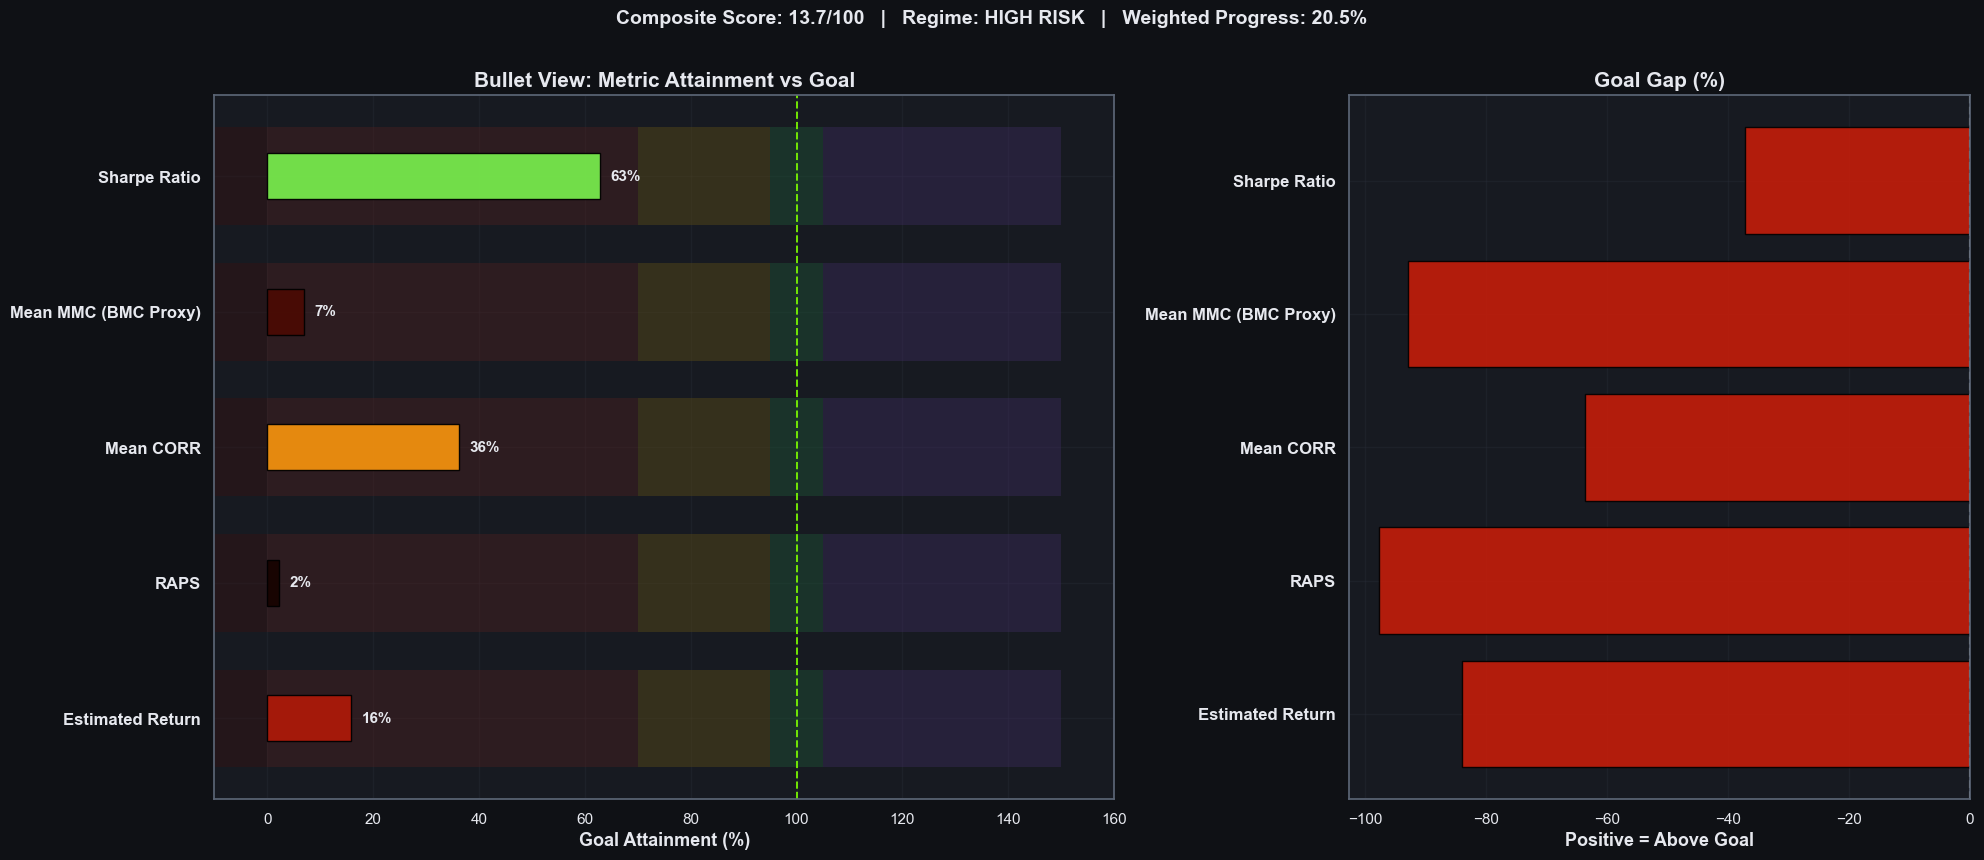

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+3.98%,+25.00%,-84.1%,15.9%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,RAPS,+0.0022,+0.1000,-97.8%,2.2%,🔴 BELOW,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),+0.00070,+0.01000,-93.0%,7.0%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,+0.00798,+0.02200,-63.7%,36.3%,🔴 BELOW,Official Numerai correlation score; strong models are often 0.01-0.03
Quality,Win Rate,75.8%,85.0%,-10.8%,89.2%,🟡 CLOSE,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Payout Sharpe,+0.2271,+1.2500,-81.8%,18.2%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Max Drawdown,-0.17236,-0.10000,-72.4%,27.6%,🔴 BELOW,Worst sustained CORR cumulative loss
Risk,Sharpe Ratio,+0.6280,+1.0000,-37.2%,62.8%,🟠 LAGGING,Risk-adjusted return consistency
Risk,MMC Volatility,+0.01087,—,—,—,—,Standard deviation of era-by-era MMC


In [44]:
evaluation_frame = build_evaluation_frame(
    validation=validation_model_frame,
    predictions= final_validation_predictions,
    target_col=MAIN_TARGET,
)

metrics, per_era_df = calculate_metrics(
    df_validation=evaluation_frame,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
 )

print("\nMeta-learner metrics:")
display_metrics_table(metrics, extended=True)

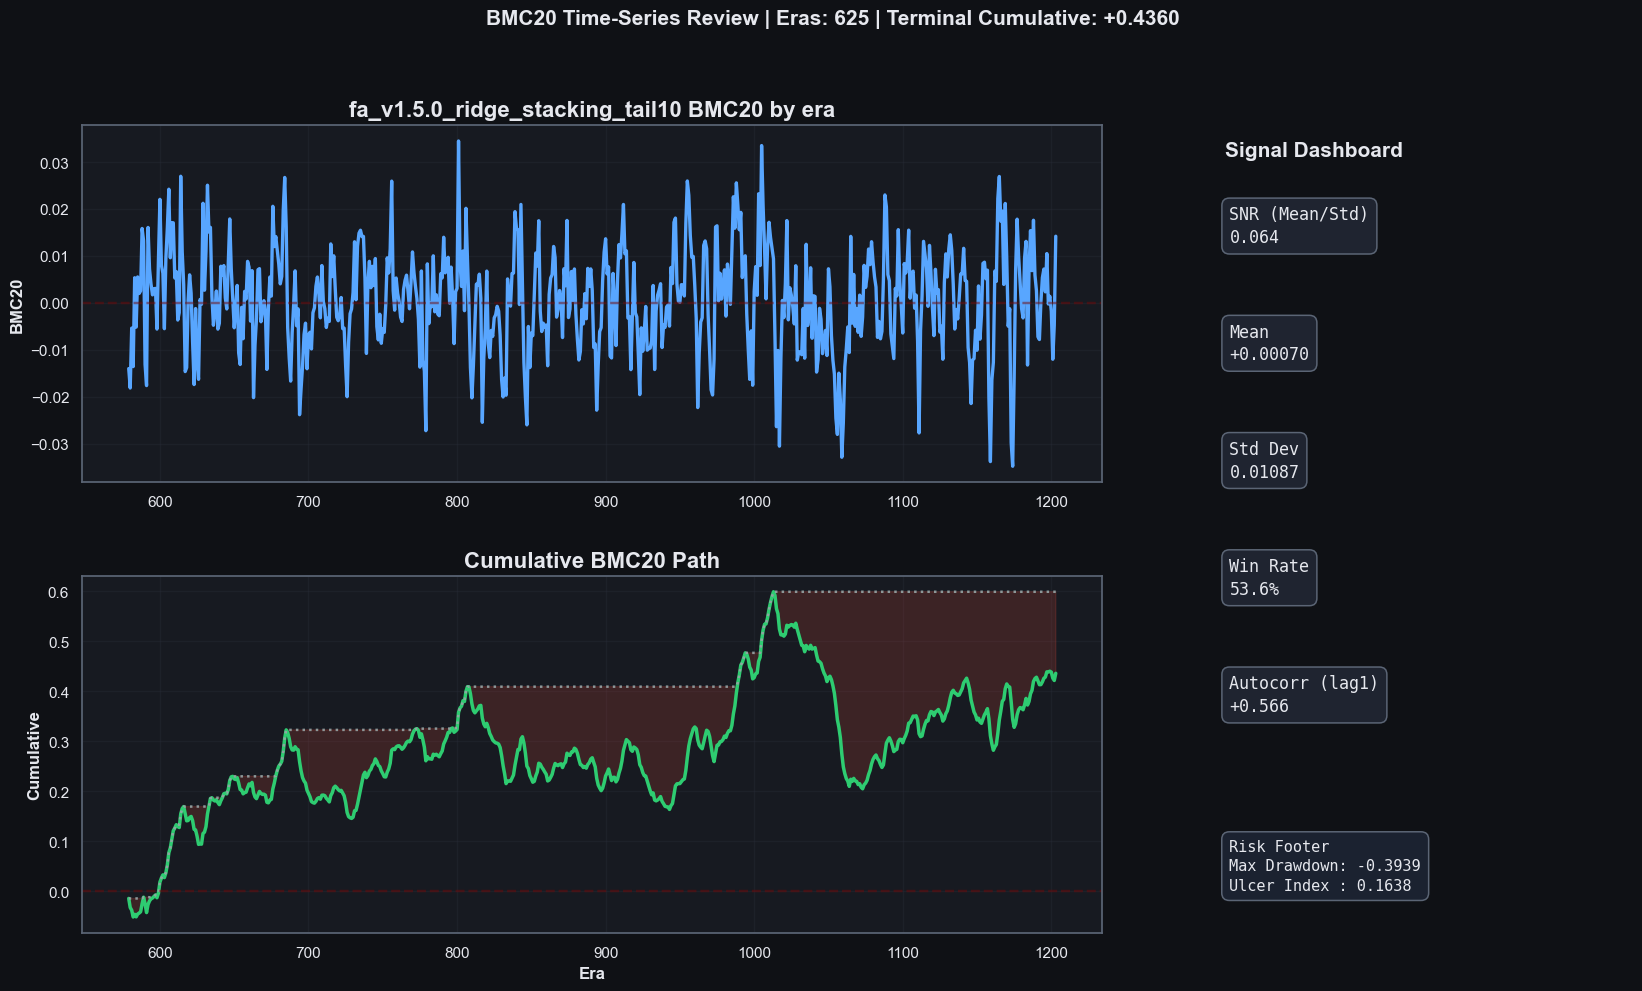

In [45]:
plot_metric_over_time(
    per_era_df=per_era_df,
    metric="BMC20",
    title=f"{MODEL_NAME} BMC20 by era",
)


In [46]:
assert False

AssertionError: 

In [47]:
history_df, record = record_model_metrics(
    metrics=metrics,
    model_name=MODEL_NAME,
    notebook_name=NOTEBOOK_PATH.name,
    force=FORCE_HISTORY_OVERWRITE,
)
display(pd.DataFrame([record]))


,run_id,model_name,9_Annualized_Return_PCT,4_Mean_BMC20,3_Mean_CORR20V2,1_RAPS,5_Sharpe_CORR,2_Sharpe_Payout,7_Max_Drawdown_CORR,8_Win_Rate,6_Mean_FNC,10_Benchmark_Corr,11_BMC_Volatility,4_Mean_MMC20,11_MMC_Volatility,notebook_name,timestamp_utc,history_path,status,message
0,8335c597,fa_v1.5.0_ridge_stacking_tail10,3.9758,0.000698,0.007982,0.002197,0.62804,0.22707,-0.17236,0.7584,NaN,0.25089,0.010871,0.000698,0.010871,notebook.ipynb,2026-04-06 19:43:31,C:\dev\numer-AI\submissions\model_metrics_hist...,overwritten,Overwrote existing model metrics (force=True a...


In [48]:
if record.get("run_id") is None:
    print("Leaderboard comparison skipped because no run was recorded.")
else:
    leaderboard, is_top_model = compare_top_models_with_current(
        current_run_id=record["run_id"],
        top_n=5,
    )

rank,run id,model name,Annualized Return PCT,Mean BMC20,Mean CORR20V2,RAPS,Sharpe CORR,Sharpe Payout,Max Drawdown CORR,Win Rate,Mean FNC,Benchmark Corr,BMC Volatility,MMC Volatility,timestamp utc
#1,dc554dd6,fa_v1.5.1_lgbm_decorr0.00_neu0.50TOP 1,+15.994%,+0.0021668,+0.03163,+1.2347,+1.8778,+1.281,-0.054067,+0.97307,-,+0.85596,+0.0058049,+0.0058049,2026-04-03 19:10:26
#2,fbb644a7,Shallow LGBM BaselineTOP 2,+5.1137%,-0.00017024,+0.013375,+0.15662,+0.96102,+0.29741,-0.081574,+0.8224,-,+0.39982,+0.010492,+0.010492,2026-04-06 19:03:43
#3,8335c597,fa_v1.5.0_ridge_stacking_tail10TOP 3CURRENT RUN,+3.9758%,+0.00069765,+0.0079816,+0.0021969,+0.62804,+0.22707,-0.17236,+0.7584,-,+0.25089,+0.010871,+0.010871,2026-04-06 19:43:31
#4,7d85f24f,ridge_baseline_template,+3.6996%,-0.00038894,+0.010567,-0.26594,+0.7651,+0.2014,-0.158,+0.7744,-,+0.32543,+0.011406,+0.011406,2026-03-29 18:15:25
#5,096fface,previous_era_target_mean,-0.25314%,-8.3872e-05,-0.00032203,-0.19054,-0.026164,-0.012723,-0.36695,+0.47218,-,+7.5847e-05,+0.011045,+0.011045,2026-03-29 18:20:57


## 5) Full-Data Retrain Setup
Specialists are trained on the **90% specialist train eras** (same split as research phase) **plus ALL of validation**.  
The meta-learner is trained on the **same 10% tail from train** (`meta_train_frame`) used in the research phase — keeping the meta-training data identical and leak-free.  
Validation is never used to train the meta-learner.

In [49]:
# Full-data retrain setup.
# Specialists: trained on 90% of train (specialist_train_frame eras) + ALL of validation.
# Meta-learner: trained on the same 10% tail from train (meta_train_frame) as in research phase.
# This mirrors the research-phase stacking split exactly — no new meta split is needed.
# Validation is safely included in specialist training because it is temporally after
# the meta tail, so no specialist-to-meta leakage is introduced.

full_validation = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_validation = full_validation.dropna(subset=[MAIN_TARGET])

# Meta training data: reuse the 10% train tail from the research phase directly.
full_meta_train_frame = meta_train_frame.copy()

# Specialist training data: 90% of train (excluding meta tail + embargo) + ALL of validation.
full_specialist_train_frame = pd.concat(
    [specialist_train_frame.dropna(subset=TARGET_COL), full_validation], axis=0
)
full_specialist_train_frame = (
    full_specialist_train_frame[~full_specialist_train_frame.index.duplicated(keep="last")]
    .sort_index()
)

# Full dataset for scoring at export time (all train + all validation rows).
full_dataset = pd.concat([train.dropna(subset=TARGET_COL), full_validation], axis=0)
full_dataset = full_dataset[~full_dataset.index.duplicated(keep="last")].sort_index()

if full_specialist_train_frame.empty or full_meta_train_frame.empty:
    raise ValueError("Full-data split produced empty specialist or meta frame.")

print(f"Meta policy                 : reusing 10% train tail from research phase = {len(meta_train_tail_eras)} eras")
print("Full meta train eras        :", (full_meta_train_frame["era"].min(), full_meta_train_frame["era"].max()))
print("Meta embargo eras excluded  :", len(meta_train_embargo_eras))
print("Full specialist train rows  :", full_specialist_train_frame.shape[0])
print("Full meta train rows        :", full_meta_train_frame.shape[0])
print("Full dataset rows (scoring) :", full_dataset.shape[0])


Meta policy                 : reusing 10% train tail from research phase = 57 eras
Full meta train eras        : ('0518', '0574')
Meta embargo eras excluded  : 4
Full specialist train rows  : 6317776
Full meta train rows        : 304771
Full dataset rows (scoring) : 6641747


## 6) Full-Data Ensemble Training
Train specialists on 90% of train + ALL validation. Train the meta-learner on the 10% train tail (same held-out eras from the research phase). Score the full merged dataset for export.

In [50]:
# Retrain specialists on full data (excluding meta tail eras), then fit final meta-ensemble.
full_targets_to_train = TARGETS_TO_TRAIN if "TARGETS_TO_TRAIN" in globals() else [
    target_name
    for target_name in AUXILIARY_TARGETS
    if target_name in full_specialist_train_frame.columns and target_name != MAIN_TARGET
]
if not full_targets_to_train:
    raise ValueError("No auxiliary targets available for full-data specialist retrain.")

full_specialist_models = {}
full_meta_X = pd.DataFrame(index=full_meta_train_frame.index)

for target_name in tqdm.tqdm(full_targets_to_train, desc="Full retrain specialists", unit="target"):
    target_train_frame = full_specialist_train_frame.dropna(subset=[target_name])
    if target_train_frame.empty:
        continue

    specialist_model = Ridge(alpha=1.0e-6, random_state=42)
    specialist_model.fit(
        target_train_frame[feature_set].to_numpy(),
        target_train_frame[target_name].to_numpy(),
    )
    full_specialist_models[target_name] = specialist_model

    meta_raw = pd.Series(
        specialist_model.predict(full_meta_train_frame[feature_set].to_numpy()),
        index=full_meta_train_frame.index,
        name=target_name,
    )
    full_meta_X[target_name] = rank_by_era(
        predictions=meta_raw,
        eras=full_meta_train_frame["era"],
        index=full_meta_train_frame.index,
    )

if not full_specialist_models:
    raise ValueError("No full-data specialists trained after target-specific NaN filtering.")
if full_meta_X.empty:
    raise ValueError("Full-data meta feature matrix is empty.")

full_meta_y = full_meta_train_frame.loc[full_meta_X.index, MAIN_TARGET]
valid_meta = full_meta_y.notna()
full_meta_X = full_meta_X.loc[valid_meta].copy()
full_meta_y = full_meta_y.loc[valid_meta].copy()

if full_meta_X.empty:
    raise ValueError("No rows left for full-data meta training after NaN filtering.")

full_meta_learner_model = Ridge(alpha=META_MODEL_ALPHA, random_state=42)
full_meta_learner_model.fit(full_meta_X.to_numpy(), full_meta_y.to_numpy())

# Score the entire merged dataset.
full_stack_inputs = pd.DataFrame(index=full_dataset.index)
for target_name, specialist_model in full_specialist_models.items():
    full_raw = pd.Series(
        specialist_model.predict(full_dataset[feature_set].to_numpy()),
        index=full_dataset.index,
        name=target_name,
    )
    full_stack_inputs[target_name] = rank_by_era(
        predictions=full_raw,
        eras=full_dataset["era"],
        index=full_dataset.index,
    )

print(">> Scoring full dataset with meta-learner.")
full_raw_predictions = pd.Series(
    full_meta_learner_model.predict(full_stack_inputs.to_numpy()),
    index=full_stack_inputs.index,
    name="prediction",
)

print('>> Full dataset prediction range (pre-neutralization):', (float(full_raw_predictions.min()), float(full_raw_predictions.max())))
if ENABLE_NEUTRALIZATION:
    print(f">> Neutralization proportion: {NEUTRALIZATION_PROPORTION}")
    full_final_predictions = neutralize_by_era(
        predictions=full_raw_predictions,
        eras=full_dataset.loc[full_raw_predictions.index, "era"],
        features=full_dataset.loc[full_raw_predictions.index, feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    full_final_predictions = rank_by_era(
        predictions=full_raw_predictions,
        eras=full_dataset.loc[full_raw_predictions.index, "era"],
        index=full_raw_predictions.index,
    )

full_retrain_artifacts = {
    "specialist_models": full_specialist_models,
    "meta_model": full_meta_learner_model,
    "feature_set": feature_set,
    "meta_holdout_eras": meta_train_tail_eras,
}

print("Full specialists trained:", len(full_specialist_models))
print("Meta training rows:", len(full_meta_X))
print("Meta holdout eras:", meta_train_tail_eras)
print(
    "Final prediction range:",
    (float(full_final_predictions.min()), float(full_final_predictions.max())),
)
display(full_final_predictions.head())


Full retrain specialists: 100%|██████████| 17/17 [00:35<00:00,  2.07s/target]


>> Scoring full dataset with meta-learner.
>> Full dataset prediction range (pre-neutralization): (0.486712920817937, 0.5150797864071375)
Full specialists trained: 17
Meta training rows: 304771
Meta holdout eras: [np.int64(518), np.int64(519), np.int64(520), np.int64(521), np.int64(522), np.int64(523), np.int64(524), np.int64(525), np.int64(526), np.int64(527), np.int64(528), np.int64(529), np.int64(530), np.int64(531), np.int64(532), np.int64(533), np.int64(534), np.int64(535), np.int64(536), np.int64(537), np.int64(538), np.int64(539), np.int64(540), np.int64(541), np.int64(542), np.int64(543), np.int64(544), np.int64(545), np.int64(546), np.int64(547), np.int64(548), np.int64(549), np.int64(550), np.int64(551), np.int64(552), np.int64(553), np.int64(554), np.int64(555), np.int64(556), np.int64(557), np.int64(558), np.int64(559), np.int64(560), np.int64(561), np.int64(562), np.int64(563), np.int64(564), np.int64(565), np.int64(566), np.int64(567), np.int64(568), np.int64(569), np.int

id
n000001bc6af72d5    0.766564
n000001c6d04d3ef    0.493157
n000006487022edd    0.108915
n0000065fb5955c5    0.361111
n0000087a1c12347    0.859848
dtype: float64

In [51]:
# Export NumerAI model-upload pickle (self-contained: no repo imports at runtime).
import cloudpickle
import numpy as np

if "full_retrain_artifacts" not in globals():
    raise ValueError("Run Cell 24 first to train full-data artifacts before exporting.")

specialist_models = full_retrain_artifacts["specialist_models"]
meta_model = full_retrain_artifacts["meta_model"]
feature_cols = list(full_retrain_artifacts["feature_set"])
meta_feature_cols = list(specialist_models.keys())

if not meta_feature_cols:
    raise ValueError("No specialist models available for export.")

# Store plain numeric parameters to avoid sklearn version-coupled pickles.
specialist_params = {}
for target_name in meta_feature_cols:
    model = specialist_models[target_name]
    specialist_params[target_name] = {
        "coef": np.asarray(model.coef_, dtype=float).tolist(),
        "intercept": float(model.intercept_),
    }

meta_params = {
    "coef": np.asarray(meta_model.coef_, dtype=float).tolist(),
    "intercept": float(meta_model.intercept_),
}


def _rank_by_era_local(values: pd.Series, eras: pd.Series) -> pd.Series:
    return values.groupby(eras).rank(method="first", pct=True).astype(float)


def predict(
    live_features: pd.DataFrame,
    live_benchmark_models: pd.DataFrame,
) -> pd.DataFrame:
    del live_benchmark_models

    missing_feature_cols = [col for col in feature_cols if col not in live_features.columns]
    if missing_feature_cols:
        preview = ", ".join(missing_feature_cols[:10])
        raise ValueError(f"Missing required feature columns ({len(missing_feature_cols)}): {preview}")

    live_X_df = live_features[feature_cols].astype(float)
    live_X = live_X_df.to_numpy()
    live_eras = (
        live_features["era"].astype(str)
        if "era" in live_features.columns
        else pd.Series("0000", index=live_features.index)
    )

    live_stack_inputs = pd.DataFrame(index=live_features.index)
    for target_name in meta_feature_cols:
        params = specialist_params[target_name]
        coef = np.asarray(params["coef"], dtype=float)
        intercept = float(params["intercept"])

        raw_target_pred = pd.Series(
            live_X @ coef + intercept,
            index=live_features.index,
            name=target_name,
        )
        live_stack_inputs[target_name] = _rank_by_era_local(raw_target_pred, live_eras)

    meta_coef = np.asarray(meta_params["coef"], dtype=float)
    meta_intercept = float(meta_params["intercept"])
    raw_meta_pred = pd.Series(
        live_stack_inputs[meta_feature_cols].to_numpy() @ meta_coef + meta_intercept,
        index=live_features.index,
        name="prediction",
    )

    final_pred = _rank_by_era_local(raw_meta_pred, live_eras)
    return final_pred.clip(lower=0.0, upper=1.0).to_frame("prediction")


with open("fa_v1_5_0_re.pkl", "wb") as file_handle:
    file_handle.write(cloudpickle.dumps(predict))

print("Model-upload pickle exported:", "fa_v1_5_0_re.pkl")
print("Expected function: predict(live_features, live_benchmark_models) -> DataFrame['prediction']")
print("Export is self-contained (no dependency on local utils package at inference time).")

Model-upload pickle exported: fa_v1_5_0_re.pkl
Expected function: predict(live_features, live_benchmark_models) -> DataFrame['prediction']
Export is self-contained (no dependency on local utils package at inference time).


===============
=============
# Leaky Sanity Check

Section 4 and section 7 both evaluate on full validation — comparison is apples-to-apples.

Section 4 — partial-data (train specialists + train meta)  CORR: 0.00798
Section 7 — full-data leaky (same validation eval window)  CORR: 0.01051

Full-data leaky metrics (full validation):
                             KEY PERFORMANCE METRICS vs GOALS                             


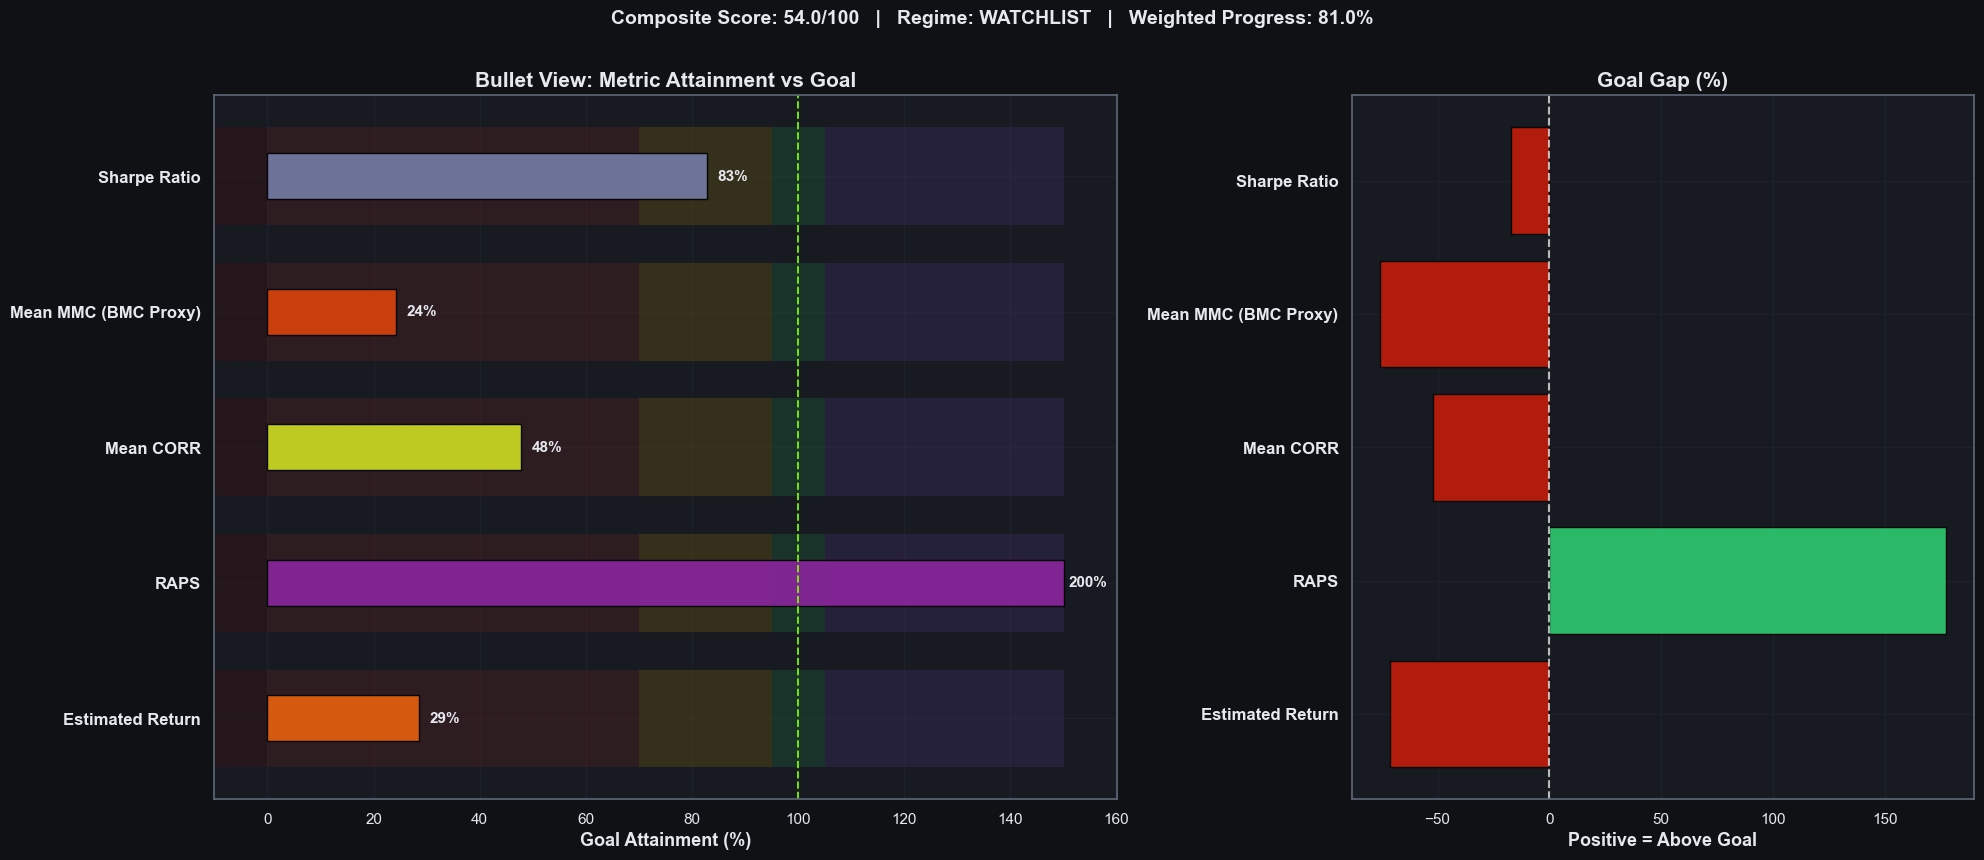

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,+7.15%,+25.00%,-71.4%,28.6%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,Mean MMC (BMC Proxy),+0.00243,+0.01000,-75.7%,24.3%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,+0.01051,+0.02200,-52.2%,47.8%,🔴 BELOW,Official Numerai correlation score; strong models are often 0.01-0.03
Payout,RAPS,+0.2771,+0.1000,+177.1%,200.0%,🟣 ABOVE TARGET !!!,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Quality,Win Rate,81.1%,85.0%,-4.6%,95.4%,🟡 CLOSE,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Payout Sharpe,+0.3996,+1.2500,-68.0%,32.0%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,Sharpe Ratio,+0.8279,+1.0000,-17.2%,82.8%,🟡 CLOSE,Risk-adjusted return consistency
Risk,Max Drawdown,-0.11634,-0.10000,-16.3%,83.7%,🟡 CLOSE,Worst sustained CORR cumulative loss
Risk,MMC Volatility,+0.01091,—,—,—,—,Standard deviation of era-by-era MMC


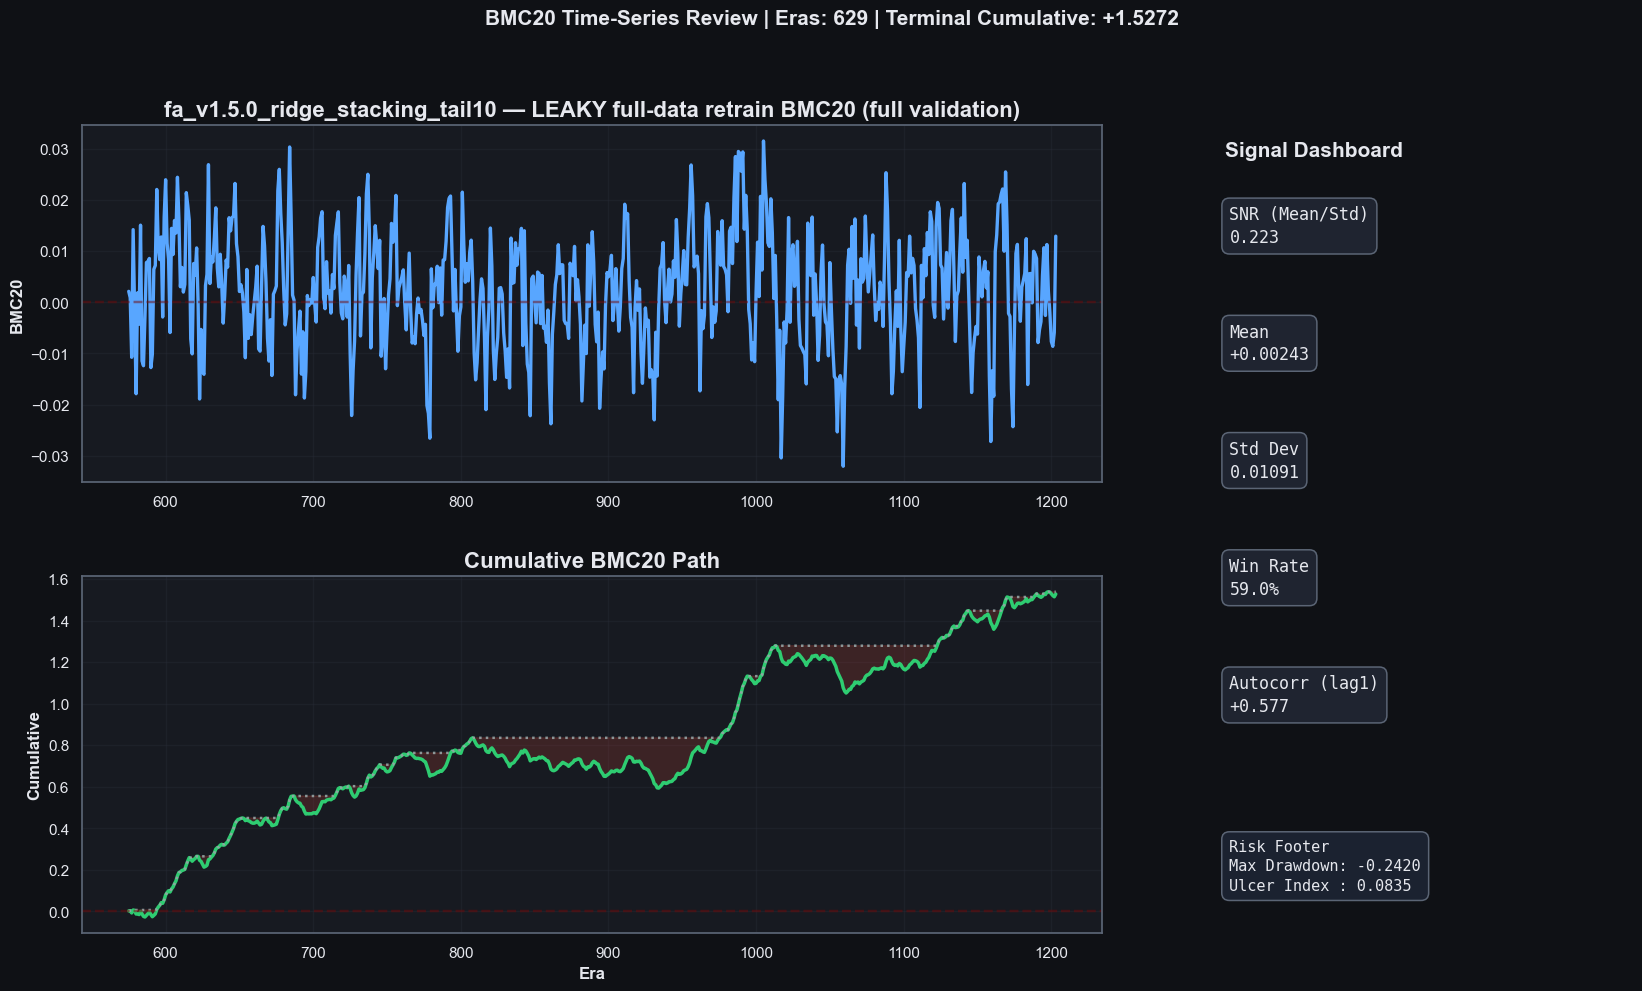

In [52]:
# 7) Apples-to-apples leaky sanity check: evaluate full-data model on the full validation set,
# the same window used in section 4.
print("WARNING: intentionally leaky — full-data specialists saw some validation-era data.")
print("Section 4 and section 7 both evaluate on full validation — comparison is apples-to-apples.")

if "full_retrain_artifacts" not in globals():
    raise ValueError("Run the full-data training cells first.")

# Reload full validation.
full_validation_eval = read_parquet_with_id_index(validation_source, columns=validation_columns)
full_validation_eval["era"] = full_validation_eval["era"].astype(int)
full_validation_eval = full_validation_eval.dropna(subset=[MAIN_TARGET]).copy()

full_val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)
full_validation_eval, full_val_benchmarks = align_on_id(full_validation_eval, full_val_benchmarks)

specialist_models = full_retrain_artifacts["specialist_models"]
meta_model = full_retrain_artifacts["meta_model"]

full_eval_stack_inputs = pd.DataFrame(index=full_validation_eval.index)
for target_name, specialist_model in specialist_models.items():
    raw_target_pred = pd.Series(
        specialist_model.predict(full_validation_eval[feature_set].to_numpy()),
        index=full_validation_eval.index,
        name=target_name,
    )
    full_eval_stack_inputs[target_name] = rank_by_era(
        predictions=raw_target_pred,
        eras=full_validation_eval["era"],
        index=full_validation_eval.index,
    )

raw_eval_pred = pd.Series(
    meta_model.predict(full_eval_stack_inputs.to_numpy()),
    index=full_eval_stack_inputs.index,
    name="prediction",
)

if ENABLE_NEUTRALIZATION:
    full_validation_leaky_predictions = neutralize_by_era(
        predictions=raw_eval_pred,
        eras=full_validation_eval.loc[raw_eval_pred.index, "era"],
        features=full_validation_eval.loc[raw_eval_pred.index, feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    full_validation_leaky_predictions = rank_by_era(
        predictions=raw_eval_pred,
        eras=full_validation_eval.loc[raw_eval_pred.index, "era"],
        index=raw_eval_pred.index,
    )

full_validation_leaky_frame = build_evaluation_frame(
    validation=full_validation_eval.loc[full_validation_leaky_predictions.index],
    predictions=full_validation_leaky_predictions,
    target_col=MAIN_TARGET,
)

full_validation_leaky_metrics, full_validation_leaky_per_era = calculate_metrics(
    df_validation=full_validation_leaky_frame,
    benchmarks=full_val_benchmarks,
    features=feature_set,
    target_col=MAIN_TARGET,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
)

corr_key = "3_Mean_CORR20V2" if "3_Mean_CORR20V2" in metrics else "3_Mean_CORR"
print(f"\nSection 4 — partial-data (train specialists + train meta)  CORR: {metrics.get(corr_key, '?'):.5f}")
print(f"Section 7 — full-data leaky (same validation eval window)  CORR: {full_validation_leaky_metrics.get(corr_key, '?'):.5f}")
print("\nFull-data leaky metrics (full validation):")
display_metrics_table(full_validation_leaky_metrics, extended=True)

plot_metric_over_time(
    per_era_df=full_validation_leaky_per_era,
    metric="BMC20",
    title=f"{MODEL_NAME} — LEAKY full-data retrain BMC20 (full validation)",
)
